# 03 — Eras, runway volume, and the FA-ist's pyramid

Two questions, both convention-dependent:

1. **How much has to exist at a grade before the next one appears?** For each
   breakthrough, count the routes already established at the outgoing top
   grade — the "runway" — under both conventions.
2. **What did the breakthrough climber's own record look like at that
   moment?** The FA-ist's pyramid, built from their *prior first ascents* in
   this dataset.

Two honest limits, stated up front. This dataset records **first ascents
only**, so the pyramids are FA pyramids — Ondra's repeats of other 9b's
before Change are invisible here, only his own FAs count. And the site is a
retrospective community record: routes climbed in the 1980s were entered
decades later, so early-era volumes reflect what the community remembered to
record (survivorship), not what a contemporary guidebook would have shown.

In [1]:
import numpy as np
import pandas as pd

from sportgradehistory import config
from sportgradehistory.grades import FRENCH_SCALE, french_ordinal
from sportgradehistory.milestones import breakthrough_table, load_sport

sport = load_sport()
BASE = french_ordinal("8a+")

tables = {c: breakthrough_table(sport, c) for c in ("as_proposed", "as_consensus")}

# The grade a route counts at, per convention.
grade_col = {"as_proposed": "proposed_order", "as_consensus": "grade_order"}

## The runway: routes at the top grade when the next one arrived

For breakthrough into grade *g+1* at date *t*: how many routes of grade *g*
(under the same convention) already had a first ascent before *t*? Year-only
FA dates are anchored to 1 January, so counts near a breakthrough can be off
by the handful of routes dated only to the breakthrough year — era edges are
soft by nature here.

In [2]:
rows = []
for convention, t in tables.items():
    col = grade_col[convention]
    for i in range(1, len(t)):
        target = t.iloc[i]
        prev_ordinal = t.iloc[i - 1]["grade_order"]
        runway = sport[
            (sport[col] == prev_ordinal)
            & sport["first_ascent"].notna()
            & (sport["first_ascent"] < target["first_ascent"])
        ]
        rows.append({
            "convention": convention,
            "into_grade": target["grade"],
            "breakthrough": target["first_ascent"].date(),
            "at_grade": FRENCH_SCALE[int(prev_ordinal)],
            "routes_on_runway": len(runway),
        })

era = pd.DataFrame(rows)
era.to_csv(config.PROCESSED_DIR / "era_runway_volumes.csv", index=False)
pivot = era.pivot_table(index="into_grade", columns="convention",
                        values="routes_on_runway", sort=False)
print(pivot.to_string())

convention  as_proposed  as_consensus
into_grade                           
8b                  5.0           5.0
8b+                 2.0           2.0
8c                  5.0           5.0
8c+                 5.0           5.0
9a                  2.0           1.0
9a+                17.0           7.0
9b                 10.0          18.0
9b+                10.0           8.0
9c                  3.0           3.0


Three regimes, not two. Through the Güllich years the runway was nearly
empty (one to five routes) — the pioneers outran the sport's ability to
consolidate. The middle grades waited for real volume: 9a+ arrived over a
17-route 9a runway (proposed reading), 9b over 10–18 at 9a+. Then the runway
*thins again at the top*: 9c arrived with only **three** 9b+'s standing —
at the extreme, the ceiling moves on the strength of one or two people, and
volume never accumulates before the next step. The conventions disagree most
exactly where the regrades cluster (8c+/9a/9a+/9b), because consensus moves
routes between runways retroactively.

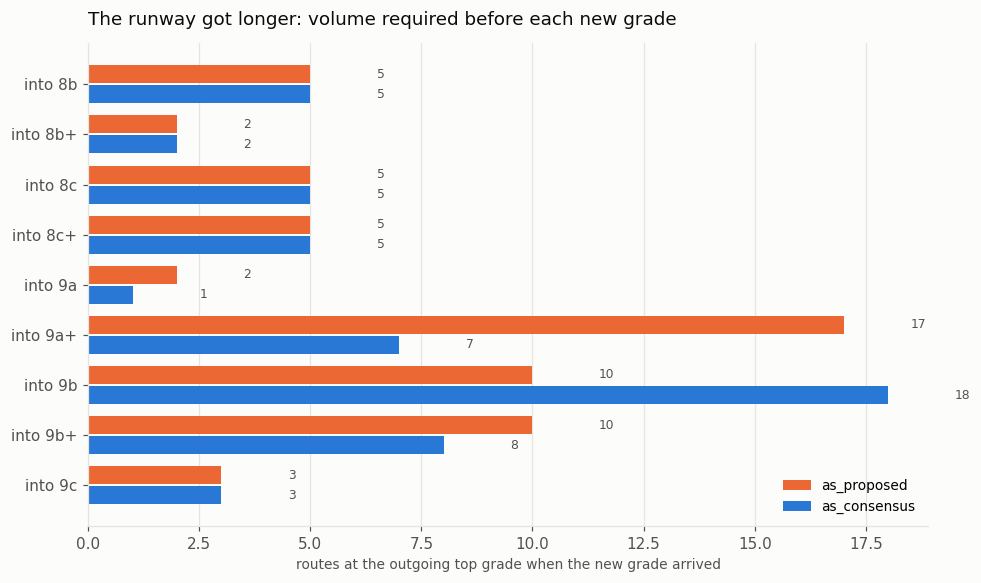

In [3]:
import matplotlib.pyplot as plt

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
BLUE, ORANGE = "#2a78d6", "#eb6834"

grades = pivot.index.tolist()
y = np.arange(len(grades))
fig, ax = plt.subplots(figsize=(9, 5.4), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for offset, (conv, color) in zip((-0.2, 0.2),
                                 (("as_proposed", ORANGE), ("as_consensus", BLUE))):
    vals = pivot[conv].to_numpy()
    ax.barh(y + offset, vals, height=0.36, color=color, label=conv, zorder=2)
    for yi, v in zip(y + offset, vals):
        ax.text(v + 1.5, yi, f"{int(v)}", va="center", fontsize=8, color=MUTED)
ax.set_yticks(y); ax.set_yticklabels([f"into {g}" for g in grades], color=INK)
ax.invert_yaxis()
ax.set_xlabel("routes at the outgoing top grade when the new grade arrived",
              color=MUTED, fontsize=9)
ax.grid(axis="x", color=GRID, lw=.8, zorder=0)
for side in ("top", "right"): ax.spines[side].set_visible(False)
for side in ("left", "bottom"): ax.spines[side].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_title("The runway got longer: volume required before each new grade",
             color=INK, fontsize=12, loc="left", pad=12)
plt.tight_layout(); plt.show()

## Routes established per era

An era runs from one consensus breakthrough to the next. How much hard
climbing (8a+ and up, consensus grades) was established during each?

In [4]:
t = tables["as_consensus"]
bounds = list(t["first_ascent"]) + [pd.Timestamp("2026-09-09")]
labels = [f"{a} era" for a in t["grade"]]
hard = sport[(sport["grade_order"] >= BASE) & sport["first_ascent"].notna()]

era_counts = pd.Series(
    pd.cut(hard["first_ascent"], bins=bounds, labels=labels, right=False)
).value_counts().reindex(labels, fill_value=0)
per_year = {
    lab: era_counts[lab] / max((b2 - b1).days / 365.25, 0.1)
    for lab, b1, b2 in zip(labels, bounds[:-1], bounds[1:])
}
out = pd.DataFrame({"routes_established": era_counts,
                    "per_year": pd.Series(per_year).round(1)})
print(out.to_string())

         routes_established  per_year
8a+ era                   6       3.3
8b era                    1       5.3
8b+ era                  23      11.5
8c era                   60      18.5
8c+ era                   1       4.8
9a era                   94      16.9
9a+ era                 267      21.0
9b era                  205      50.5
9b+ era                 204      41.5
9c era                  718      79.6


## The FA-ist's pyramid at the moment of breakthrough

For each `as_consensus` milestone: the climber's own prior first ascents in
this dataset, by consensus grade, strictly before the breakthrough date. A
`-` row means the site records no prior FA for them at all — for the early
Güllich milestones that is partly survivorship, partly the man simply moving
that fast.

In [5]:
t = tables["as_consensus"]
pyr_rows = []
for _, m in t.iterrows():
    prior = sport[
        (sport["first_climber"] == m["climber"])
        & sport["first_ascent"].notna()
        & (sport["first_ascent"] < m["first_ascent"])
        & (sport["grade_order"] >= french_ordinal("7c"))
    ]
    counts = prior["grade_clean"].value_counts()
    counts = counts.reindex(sorted(counts.index, key=french_ordinal))
    pyramid = "  ".join(f"{g}x{n}" for g, n in counts.items()) or "-"
    pyr_rows.append({"milestone": f"{m['grade']}  {m['route']}",
                     "year": m["first_ascent"].year,
                     "climber": m["climber"],
                     "prior_FAs_7c_and_up": pyramid})
pyr = pd.DataFrame(pyr_rows)
pyr.to_csv(config.PROCESSED_DIR / "milestone_fa_pyramids.csv", index=False)
print(pyr.to_string(index=False))

            milestone  year          climber                                                 prior_FAs_7c_and_up
        8a+  The Face  1983    Jerry Moffatt                                                         7c+x2  8ax1
  8b  Kanal im Rücken  1984 Wolfgang Güllich                                                         7c+x1  8ax1
8b+  Punks in the Gym  1985 Wolfgang Güllich                                                   7c+x1  8ax1  8bx1
       8c  Wallstreet  1987 Wolfgang Güllich                                            7c+x1  8ax1  8bx4  8b+x1
    8c+  Liquid Ambar  1990    Jerry Moffatt                                     7c+x5  8ax4  8a+x2  8bx1  8b+x1
           9a  Hubble  1990         Ben Moon                                                    8ax2  8bx1  8cx2
             9a+  Qui  1996     Stefan Fürst                                                                   -
       9b  Jumbo Love  2008     Chris Sharma                               8bx2  8b+x1  8cx3  8c

The modern pattern is unmistakable: Sharma reached Jumbo Love with a stack
of 8c+/9a/9a+ FAs behind him, Ondra reached Change and Silence with the
largest FA pyramid ever assembled. The early milestones ride on thin or empty
recorded pyramids — Güllich's Wallstreet and Action Directe show only a
handful of prior FAs here — which is the survivorship limit above doing its
work. Treat the pre-1995 pyramids as lower bounds, not biographies.

In [6]:
# Ondra at Silence, in full, as the extreme case.
m = t[t["route"] == "Silence"].iloc[0]
prior = sport[(sport["first_climber"] == m["climber"])
              & sport["first_ascent"].notna()
              & (sport["first_ascent"] < m["first_ascent"])
              & (sport["grade_order"] >= french_ordinal("8c"))]
print(f"Adam Ondra's recorded FAs of 8c+ and up before {m['first_ascent'].date()}: "
      f"{len(prior)}")
print(prior["grade_clean"].value_counts().reindex(
    sorted(set(prior['grade_clean']), key=french_ordinal)).to_string())

Adam Ondra's recorded FAs of 8c+ and up before 2017-09-03: 82
grade_clean
8c     12
8c+    17
9a     26
9a+    16
9b      8
9b+     3


## The same pyramids, drawn

The table above gives each breakthrough climber's prior first ascents as a
string of counts. This draws them: one pyramid per milestone, widest grade at
the bottom, narrowing towards whatever the climber had done hardest before the
breakthrough.

Two things to keep in mind while reading them.

**These are first-ascent pyramids, not ability pyramids.** A climbing pyramid
normally counts everything a person has climbed. This counts only routes they
put up first, because that is all this dataset records. Ondra had repeated a
great many 9a's he did not establish, and none of them are here. The shape is a
record of what each climber *contributed* at each grade.

**Each pyramid is scaled to its own widest tier.** Ondra's Silence pyramid
contains twenty-six 9a first ascents; Moffatt's 1983 pyramid contains two 7c+s.
Every panel is therefore normalised to itself and the counts are printed
beside each tier. Compare the *shapes* across panels, and the *numbers*
for size — or read the next section, which puts all ten on one shared
scale. That turns out to be perfectly legible: the small pyramids draw
small, not invisible, and being able to see that is the point.

In [7]:
t = tables["as_consensus"]
spyr = []
for _, m in t.iterrows():
    prior = sport[
        (sport["first_climber"] == m["climber"])
        & sport["first_ascent"].notna()
        & (sport["first_ascent"] < m["first_ascent"])
        & (sport["grade_order"] >= french_ordinal("7c"))
    ]
    counts = prior["grade_clean"].value_counts()
    counts = counts.reindex(sorted(counts.index, key=french_ordinal))
    spyr.append({
        "milestone": f"{m['grade']}  {m['route']}",
        "grade": m["grade"], "route": m["route"],
        "climber": m["climber"], "year": m["first_ascent"].year,
        "n_prior_fas": int(len(prior)),
        "top_grade": counts.index[-1] if len(counts) else None,
        "pyramid": "  ".join(f"{g}x{n}" for g, n in counts.items()) or "-",
        "counts": dict(counts),
    })
spyr = pd.DataFrame(spyr)
spyr.drop(columns="counts").to_csv(
    config.PROCESSED_DIR / "milestone_sport_pyramids.csv", index=False)
print(spyr.drop(columns=["counts", "grade", "route"]).to_string(index=False))

            milestone          climber  year  n_prior_fas top_grade                                                             pyramid
        8a+  The Face    Jerry Moffatt  1983            3        8a                                                         7c+x2  8ax1
  8b  Kanal im Rücken Wolfgang Güllich  1984            2        8a                                                         7c+x1  8ax1
8b+  Punks in the Gym Wolfgang Güllich  1985            3        8b                                                   7c+x1  8ax1  8bx1
       8c  Wallstreet Wolfgang Güllich  1987            7       8b+                                            7c+x1  8ax1  8bx4  8b+x1
    8c+  Liquid Ambar    Jerry Moffatt  1990           13       8b+                                     7c+x5  8ax4  8a+x2  8bx1  8b+x1
           9a  Hubble         Ben Moon  1990            5        8c                                                    8ax2  8bx1  8cx2
             9a+  Qui     Stefan Fürst  1996    

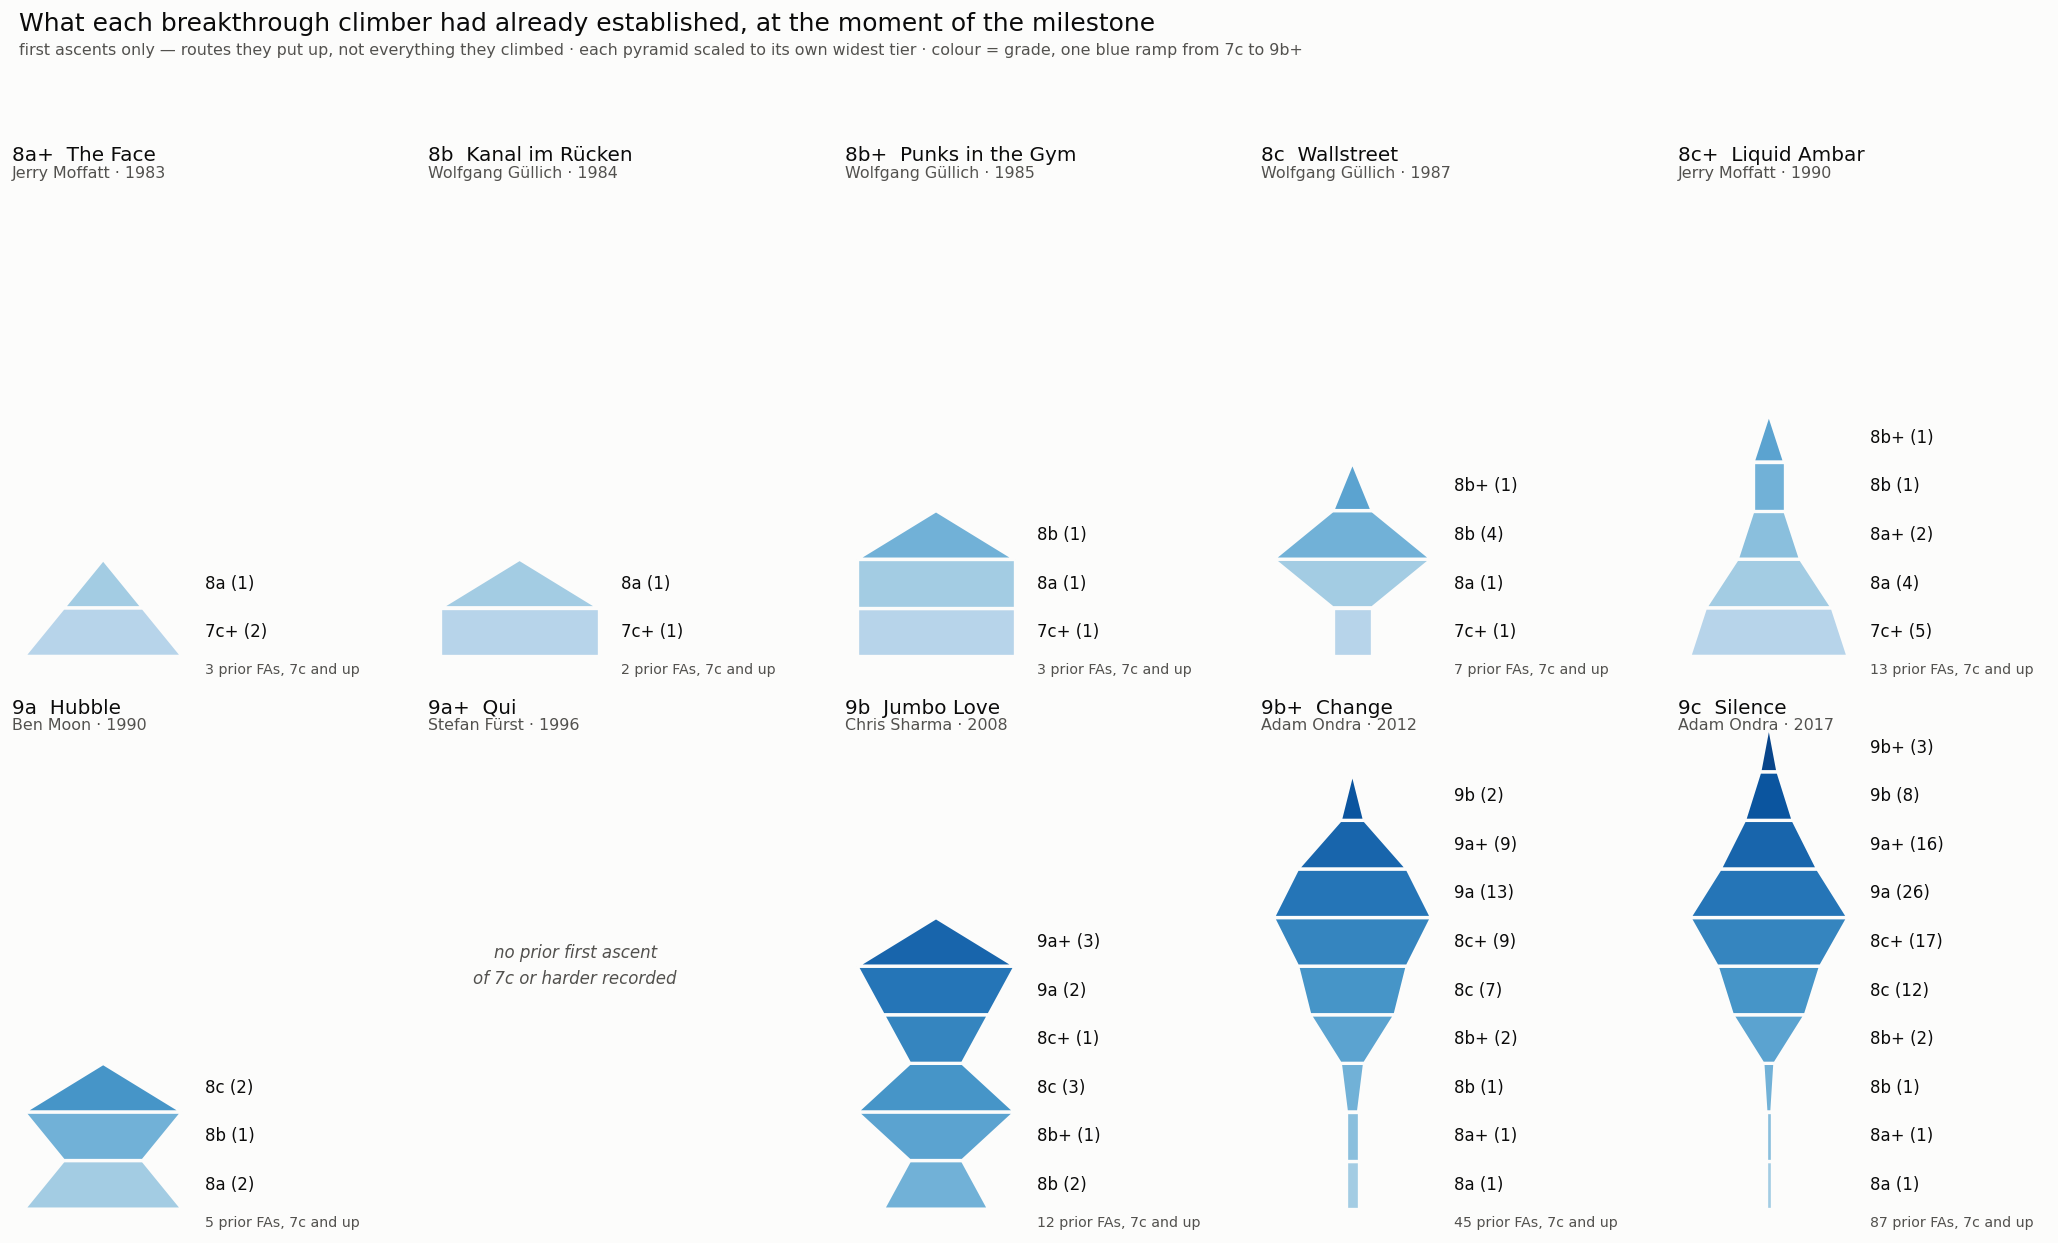

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

PAPER, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e4e0"

# Every grade that appears anywhere, easiest first. Colour is keyed to the
# grade, not to the tier's position, so a colour means the same thing in all
# ten panels.
ALL_GRADES = sorted({g for c in spyr["counts"] for g in c}, key=french_ordinal)
MAXROWS = max(len(c) for c in spyr["counts"])
GW = 1.0                                     # half-width of a panel's widest tier


def draw_pyramids(grade_color, path, note):
    fig, axes = plt.subplots(2, 5, figsize=(17.5, 10.5), dpi=120, facecolor=PAPER)

    for ax, (_, row) in zip(axes.ravel(), spyr.iterrows()):
        ax.set_facecolor(PAPER)
        ax.set_xlim(-GW * 1.15, GW * 3.5)
        ax.set_ylim(-0.45, MAXROWS + 0.55)
        ax.axis("off")

        ax.text(-GW * 1.15, MAXROWS + 0.50, f"{row['grade']}  {row['route']}",
                fontsize=12, color=INK, ha="left", va="top")
        ax.text(-GW * 1.15, MAXROWS + 0.10,
                f"{row['climber']} · {row['year']}", fontsize=9.5, color=MUTED,
                ha="left", va="top")

        counts = row["counts"]
        if not counts:
            ax.text(GW * 0.7, MAXROWS / 2,
                    "no prior first ascent\nof 7c or harder recorded",
                    fontsize=10, color=MUTED, ha="center", va="center",
                    linespacing=1.6, style="italic")
            continue

        grades = sorted(counts, key=french_ordinal)          # easiest at the bottom
        widest = max(counts.values())                        # per-panel scale
        widths = [GW * counts[g] / widest for g in grades]
        for i, g in enumerate(grades):
            wb = widths[i]
            wt = widths[i + 1] if i + 1 < len(grades) else 0.0   # apex to a point
            ax.add_patch(Polygon([(-wb, i), (wb, i), (wt, i + 1), (-wt, i + 1)],
                                 closed=True, facecolor=grade_color[g],
                                 edgecolor=PAPER, lw=2, zorder=2))
            ax.text(GW * 1.28, i + 0.5, f"{g} ({counts[g]})", fontsize=10,
                    color=INK, ha="left", va="center")

        ax.text(GW * 1.28, -0.28, f"{row['n_prior_fas']} prior FAs, 7c and up",
                fontsize=8.5, color=MUTED, ha="left", va="center")

    fig.suptitle("What each breakthrough climber had already established, at the "
                 "moment of the milestone", color=INK, fontsize=15, x=.012,
                 ha="left", y=.982)
    fig.text(.012, .948,
             "first ascents only — routes they put up, not everything they climbed · "
             "each pyramid scaled to its own widest tier · " + note,
             fontsize=9.5, color=MUTED)
    plt.tight_layout(rect=(0, 0, 1, 0.925))
    plt.savefig(path, facecolor=PAPER, bbox_inches="tight")
    plt.show()


# One hue, light to dark: grade is ordinal, so a single ramp reads as ordered.
blues = plt.cm.Blues(np.linspace(0.30, 0.92, len(ALL_GRADES)))
draw_pyramids(dict(zip(ALL_GRADES, blues)),
              config.FIGURES_DIR / "milestone_sport_pyramids.png",
              "colour = grade, one blue ramp from 7c to 9b+")

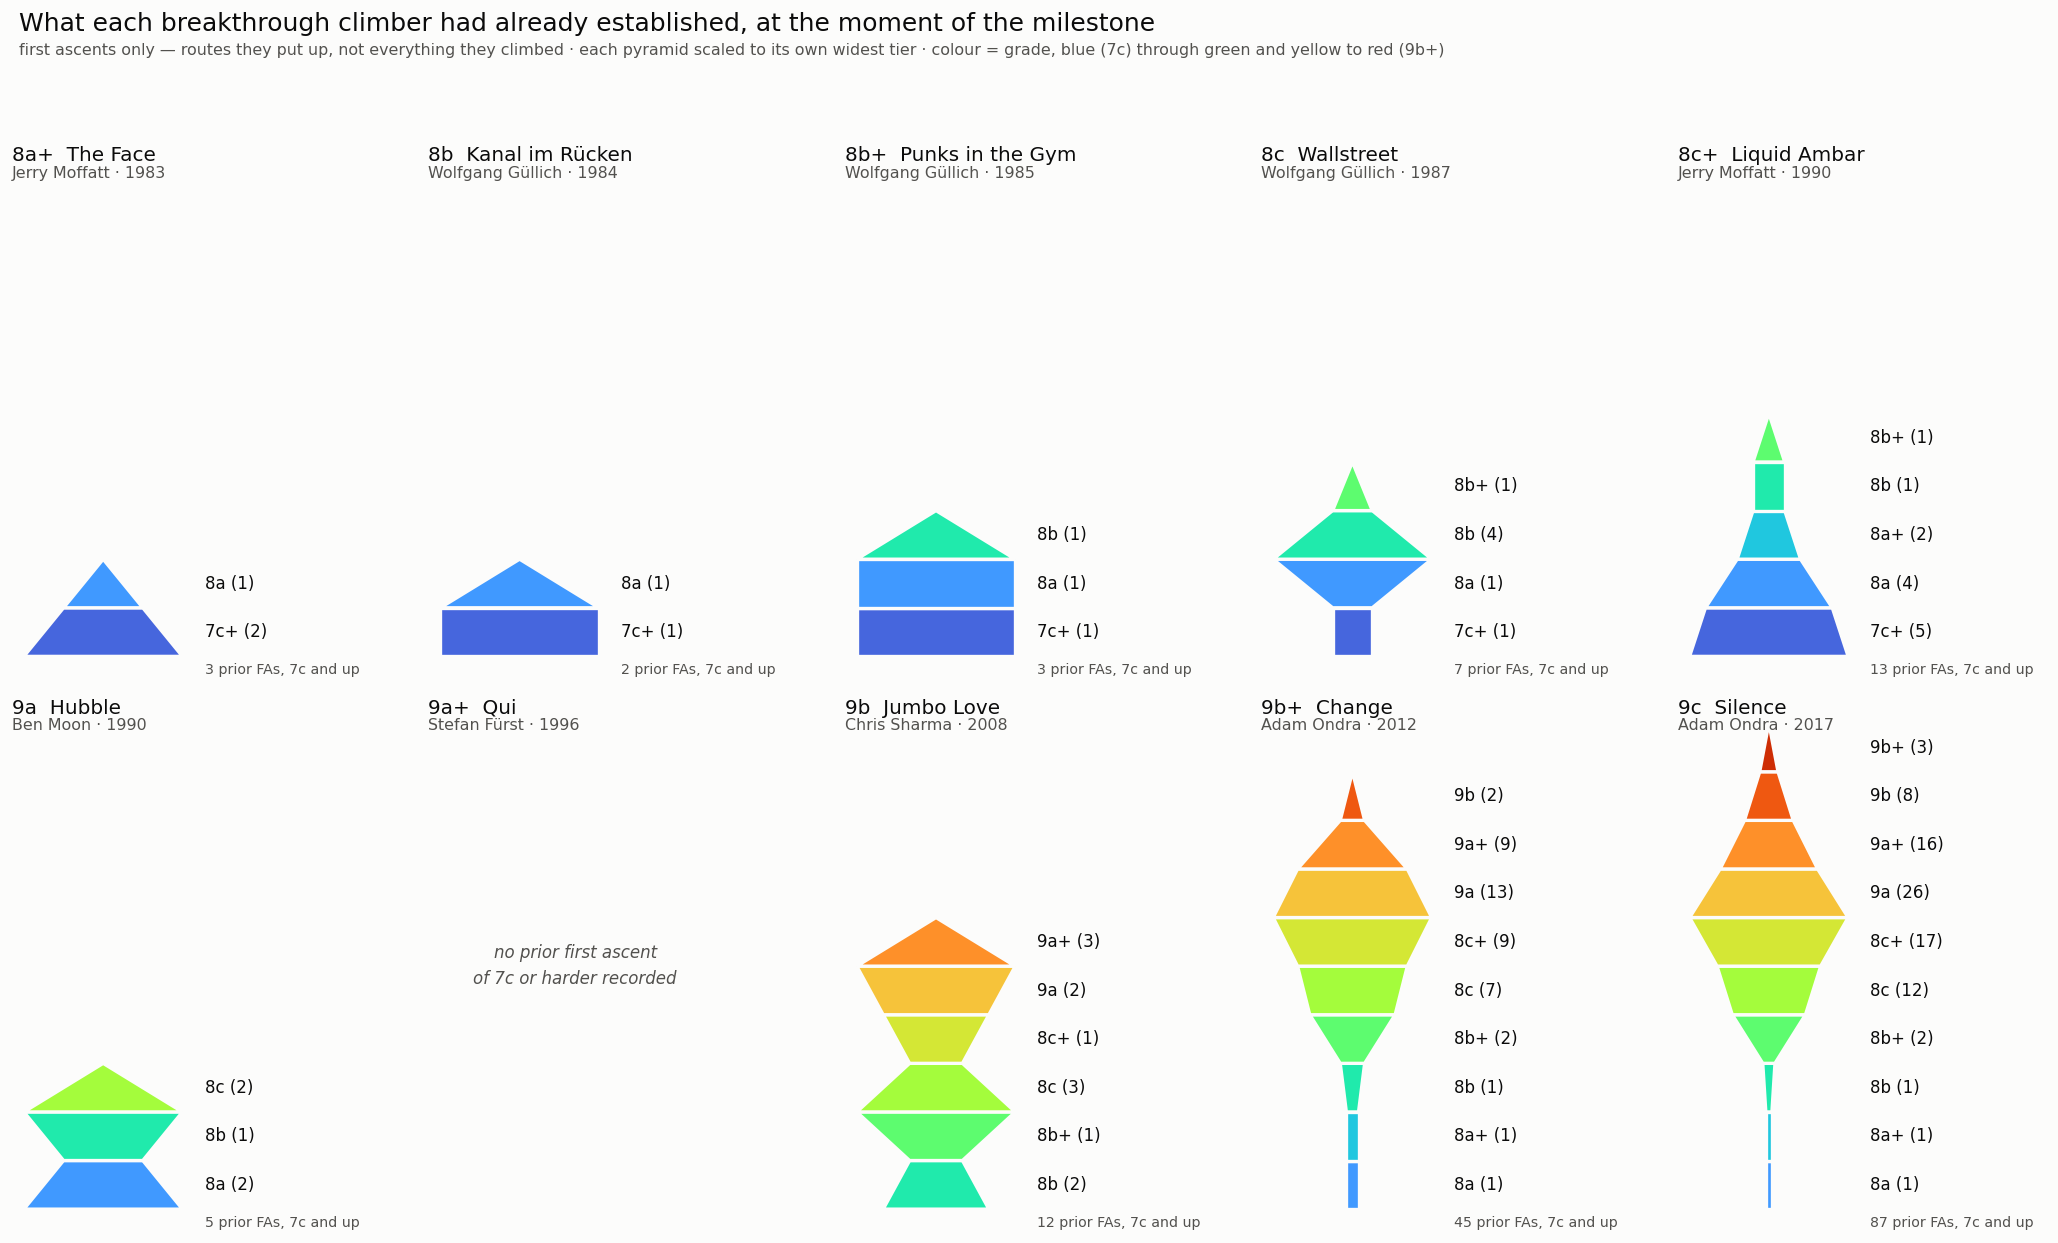

In [9]:
# The poster variant: the same data on a blue-green-yellow-red progression, as
# in the pyramids climbers draw for themselves. Easier to read across a room
# and easier to tell two adjacent tiers apart; the single-hue version above is
# the better one for judging order at a glance.
warm = plt.cm.turbo(np.linspace(0.12, 0.88, len(ALL_GRADES)))
draw_pyramids(dict(zip(ALL_GRADES, warm)),
              config.FIGURES_DIR / "milestone_sport_pyramids_colour.png",
              "colour = grade, blue (7c) through green and yellow to red (9b+)")

**Nine of the ten milestones rest on a pyramid; one rests on nothing.**

- **Moffatt 1983 and Güllich 1984–85** stand on two or three routes apiece. Not
  because they had climbed nothing, but because in 1983 there was almost nothing
  at 7c+ and above *to have climbed* — and because the site's record of that era
  is what the community entered decades later.
- **Güllich at Wallstreet (1987)** is the first recognisable shape: four 8b's
  under an 8b+, with the 8c he was about to create on top.
- **Moffatt at Liquid Ambar (1990)** is the widest early pyramid — five 7c+s,
  four 8a's — and **Moon at Hubble (1990)** is the opposite: narrow and tall,
  two 8c's already done before the route that would become the first 9a.
- **Fürst at Qui (1996)** has no prior first ascent of 7c or harder recorded at
  all. He is the one milestone climber in this dataset with no pyramid, which is
  part of why the 9a+ slot under `as_consensus` is the least comfortable
  attribution in the whole table.
- **Sharma at Jumbo Love (2008)** is the first genuinely deep pyramid: three
  9a+s and two 9a's already established.
- **Ondra at Change (2012), then Silence (2017)**, is a different order of
  magnitude — and the five years between them nearly double it, from thirteen
  9a's to twenty-six, and from two 9b's to eight plus three 9b+s.

The shape to notice across the row is that **the pyramids stop tapering and
start bulging**. The early ones narrow towards their peak like the drawings
climbers make of their own records. Ondra's widest tier is 9a, four rungs
below Silence, with 9a+ and 9b stacked above it — a first-ascent record that
keeps widening at the top because he was establishing at the limit rather than
filling in below it.

## The same pyramids, to scale

The panels above each stand on their own scale, which answers *what shape?* and
refuses to answer *how big?*. This section fixes both scales across every panel
so the second question has an answer too. Two things have to change.

**Grade gets its own axis.** Every panel carries the same ladder from 7c+ to 9c,
so a tier's height means a grade rather than a position in that climber's own
stack — and a grade nobody in the panel has climbed shows up as a gap rather
than closing up. Self-normalised panels stack from each pyramid's own floor,
which is what makes them incomparable even before the widths differ.

**Colour stops encoding grade.** It was redundant the moment grade had an axis,
and it never really worked: thirteen grades on one blue ramp put every adjacent
pair below the distinguishable-lightness threshold and left the lightest step at
1.5:1 against this paper. The freed channel goes to something the pyramids could
not say before — whether each first ascent has since been **repeated by someone
else**. At the top of the scale that is not a detail: a grade is a proposal until
a second person confirms it.

Tiers are drawn as centred bars rather than tapering trapezoids. On a shared
scale a sloped edge puts a tier's area somewhere between its own count and its
neighbour's, which is exactly the reading this figure exists to make exact.

shared ladder 7c+-9c (12 rungs), shared count scale to 33


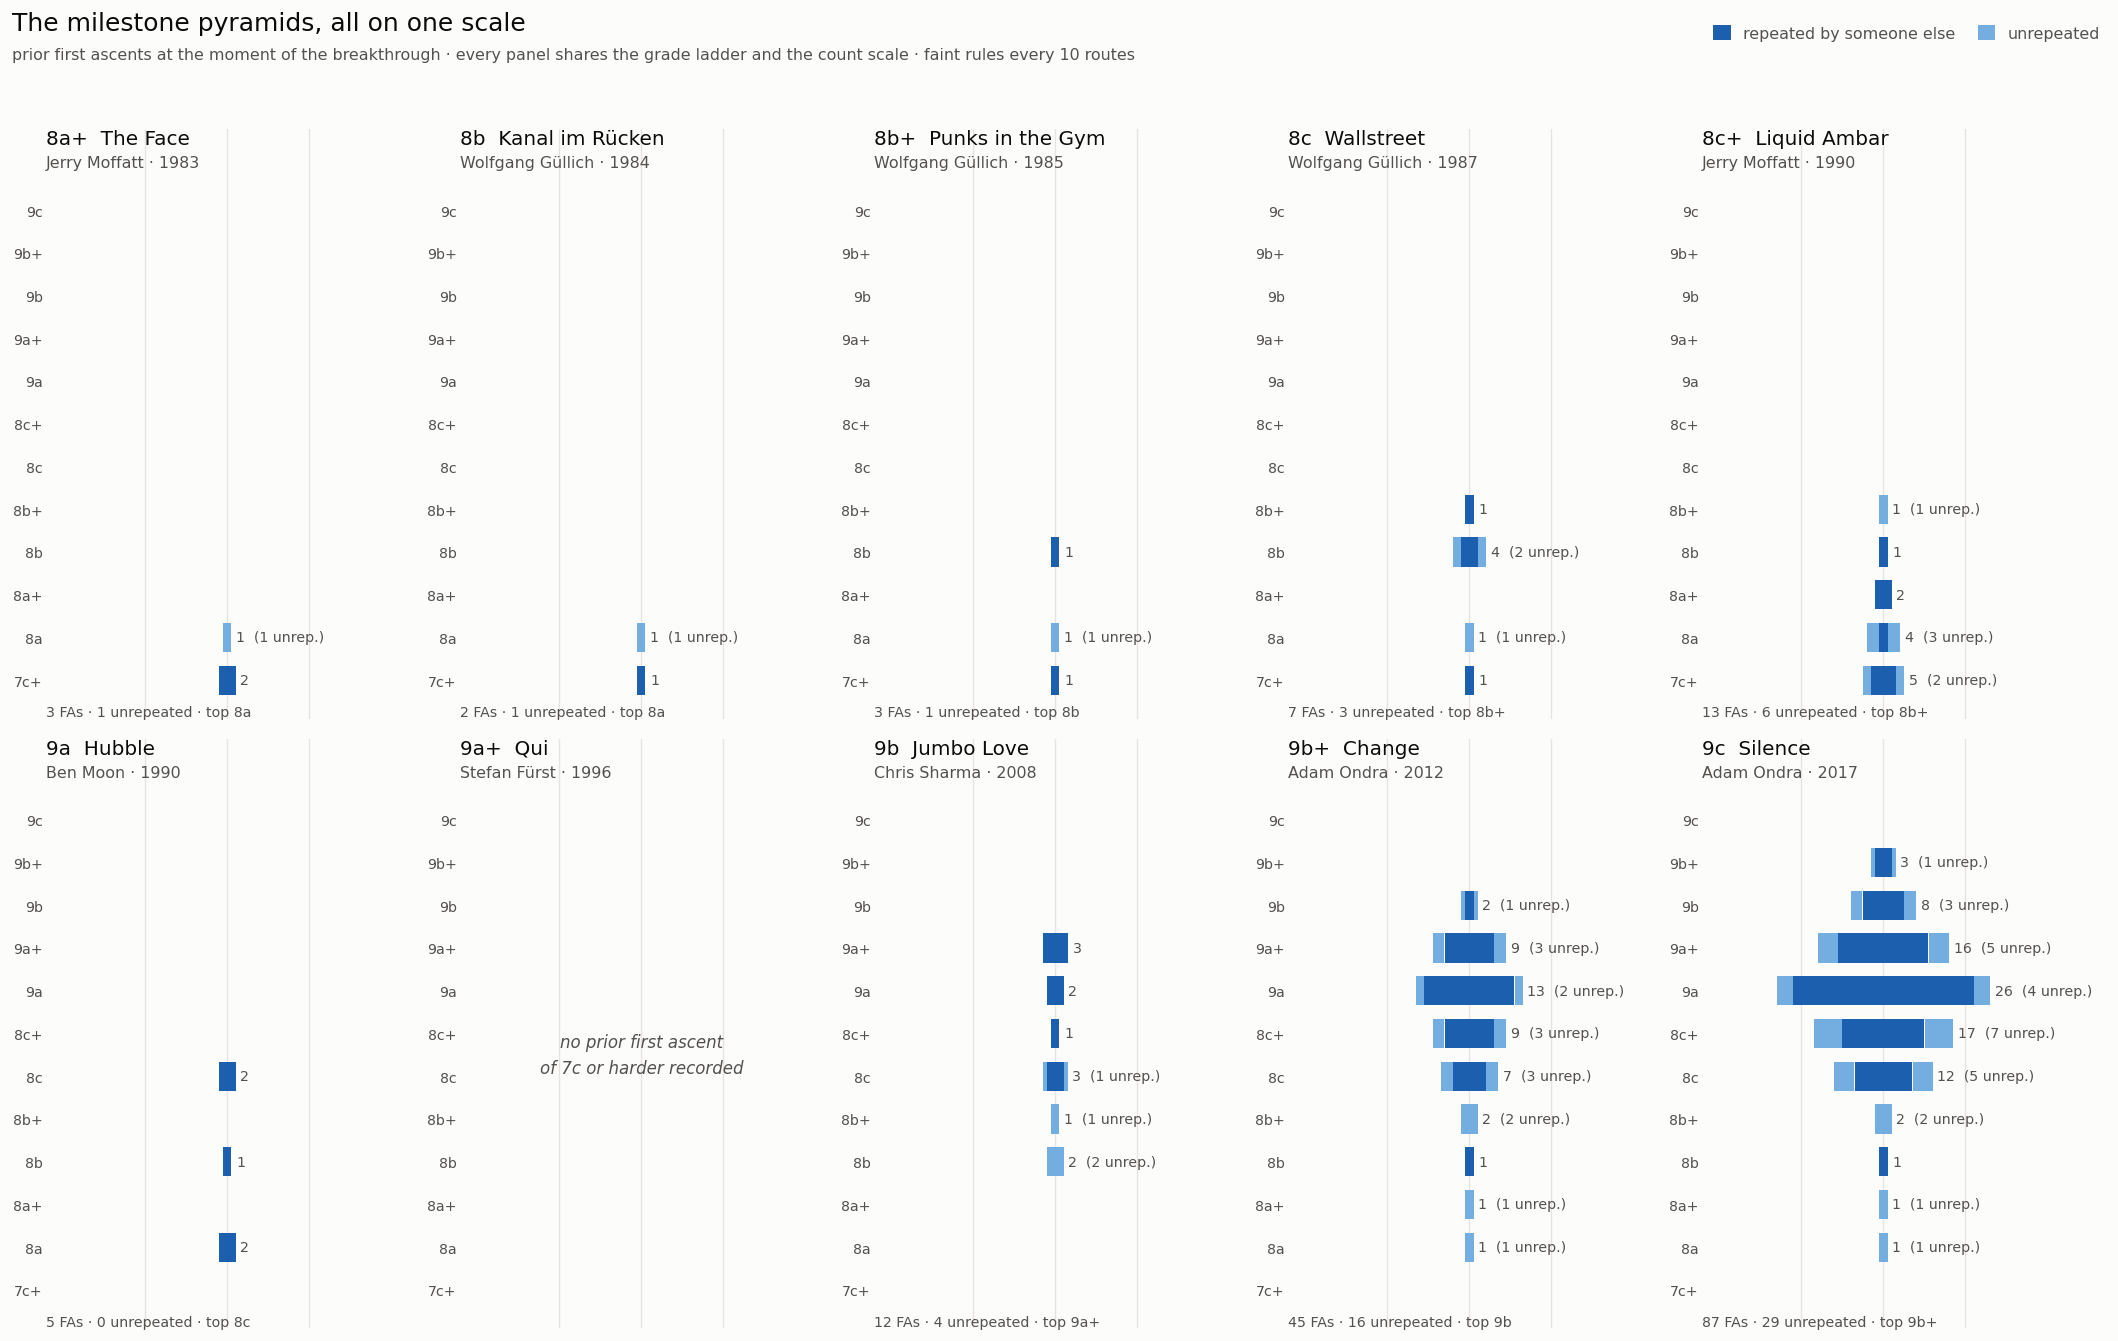

In [10]:
from sportgradehistory.pyramids import (
    climber_panels, draw_pyramid_grid, milestone_panels, panels_frame,
    shared_ladder,
)

milestones = milestone_panels(sport)
climbers = climber_panels(sport)

# One ladder and one count scale across *both* figures, so the milestone panels
# and the climber panels below are comparable to each other and not merely
# internally consistent.
ladder = shared_ladder(milestones, climbers)
widest = max(p.widest for p in milestones + climbers)
print(f"shared ladder {ladder[0]}-{ladder[-1]} ({len(ladder)} rungs), "
      f"shared count scale to {widest}")

draw_pyramid_grid(
    milestones, ladder=ladder, widest=widest, ncols=5,
    path=config.FIGURES_DIR / "milestone_pyramids_to_scale.png",
    title="The milestone pyramids, all on one scale",
    subtitle="prior first ascents at the moment of the breakthrough · "
             "every panel shares the grade ladder and the count scale · "
             "faint rules every 10 routes")
plt.show()

On one scale the growth stops being a claim and becomes a picture.

- **The first five milestones put together** — Moffatt 1983 through Liquid Ambar
  1990 — carry 28 prior first ascents between them, under a third of what Ondra
  had behind him at Silence alone. On the self-normalised figure those five look
  like fully formed pyramids; here they are the slivers they actually are.
- **The mass climbs the ladder.** Every panel's centre of gravity sits higher
  than the last: Moffatt's 1983 pyramid tops out at 8a, Wallstreet at 8b+,
  Jumbo Love at 9a+, Silence at 9b+. Because the ladder is shared, that shift is
  now a vertical movement across the figure rather than something you have to
  reconstruct from tier labels.
- **Fürst at Qui (1996) is still empty**, and on this figure the emptiness is
  measured against nine panels that are not, which is the fairest way to show it.
- **Silence is the outlier by construction.** Twenty-six 9a first ascents in one
  tier is wider than any *whole pyramid* before Jumbo Love.

The repeated/unrepeated split adds a qualifier the earlier figure could not.
**Moon at Hubble had five prior first ascents and not one of them still stands
unrepeated** — the only milestone pyramid drawn entirely in the dark step;
Fürst's is not dark, it is empty —
while a third of Ondra's Silence pyramid (29 of 87) had no second ascent at the
time of the scrape. The higher the tier, the more of it is light.

## Today's hardest first ascentionists

The same treatment, applied to the people establishing at the top of the scale
now, on the same ladder and the same count scale as the milestone figure above —
so Ondra-at-Silence and Ondra-today can be laid side by side.

One difference in definition, and it matters. The milestone pyramids are cut off
at a date: what that climber had established *before* the breakthrough. These are
career-to-date, every recorded first ascent up to the 2026-09-09 scrape. And the
standing limit of the whole notebook applies with full force here: **this dataset
records first ascents only**. Schubert and Bailey have climbed a great deal more
than they have put up, and none of it appears.

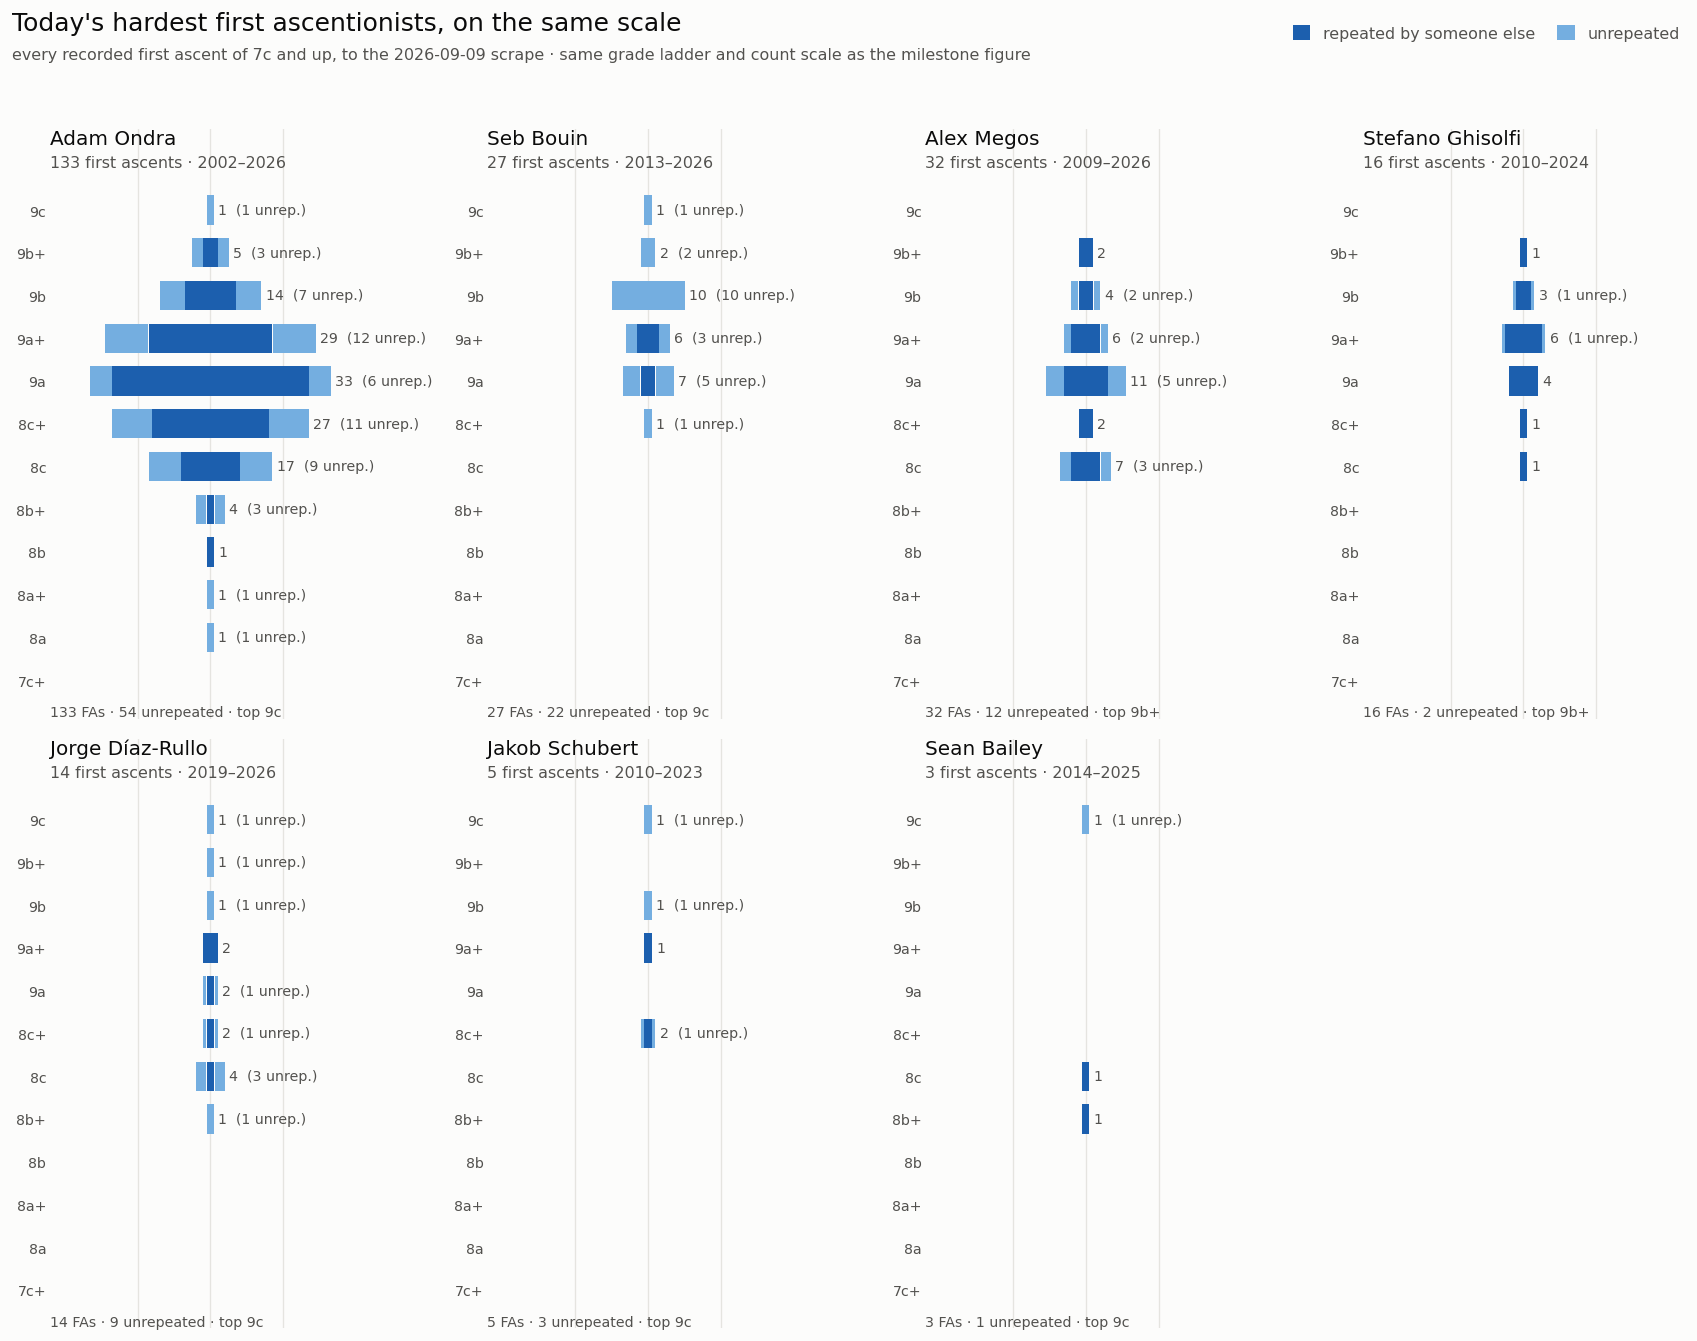

           panel  n_fas  n_unrepeated top_grade  widest_tier                                                                    pyramid
      Adam Ondra    133            54        9c           33 8ax1  8a+x1  8bx1  8b+x4  8cx17  8c+x27  9ax33  9a+x29  9bx14  9b+x5  9cx1
       Seb Bouin     27            22        9c           10                                     8c+x1  9ax7  9a+x6  9bx10  9b+x2  9cx1
      Alex Megos     32            12       9b+           11                                     8cx7  8c+x2  9ax11  9a+x6  9bx4  9b+x2
Stefano Ghisolfi     16             2       9b+            6                                      8cx1  8c+x1  9ax4  9a+x6  9bx3  9b+x1
Jorge Díaz-Rullo     14             9        9c            4                         8b+x1  8cx4  8c+x2  9ax2  9a+x2  9bx1  9b+x1  9cx1
  Jakob Schubert      5             3        9c            2                                                   8c+x2  9a+x1  9bx1  9cx1
     Sean Bailey      3             1        9c 

In [11]:
draw_pyramid_grid(
    climbers, ladder=ladder, widest=widest, ncols=4,
    path=config.FIGURES_DIR / "todays_climbers_pyramids.png",
    title="Today's hardest first ascentionists, on the same scale",
    subtitle="every recorded first ascent of 7c and up, to the 2026-09-09 "
             "scrape · same grade ladder and count scale as the milestone "
             "figure")
plt.show()

frame = pd.concat([panels_frame(milestones, "milestone"),
                   panels_frame(climbers, "climber")], ignore_index=True)
frame.to_csv(config.PROCESSED_DIR / "pyramids_to_scale.csv", index=False)
print(frame[frame["kind"] == "climber"]
      .drop(columns=["kind", "subtitle"]).to_string(index=False))

**These are not pyramids. They are stalks.**

The shape every one of the seven shares is that it has no base. Nobody here has
a recorded first ascent below 8a, and only Ondra has anything below 8b+ — one
8a, one 8a+, one 8b. A climbing pyramid is normally widest at the bottom; these
are widest three or four rungs from the top, or have no width at all. That is
what an FA record looks like when the climber's ordinary volume is repeats:
establishing is something they do at their limit, so only the limit is recorded.

- **Ondra is bigger than the other six combined** — 133 first ascents against 97
  — and his widest tier, 33 routes at 9a, is wider than any other climber's
  entire record. Against his own Silence panel above, the nine years since have
  added 46 first ascents and a 9c.
- **Bouin's 9b tier is the striking one**: ten 9b first ascents, second only to
  Ondra's fourteen, and *every one of them unrepeated*, where half of Ondra's
  have been confirmed. 81% of his whole record has no second
  ascent — the highest share here by a wide margin. He is establishing in places
  nobody else goes.
- **Ghisolfi is the mirror image**: 12% unrepeated, the lowest. Sixteen first
  ascents, fourteen of them confirmed by someone else. A record of routes that
  became part of the circuit rather than remaining propositions.
- **Schubert and Bailey barely have records at all** — five FAs and three — each
  topped by a 9c. Bailey's is the extreme: 8b+, 8c, then *Duality of Man* at 9c
  with five empty rungs in between. Read that as the dataset's limit, not as a
  biography.
- **Five of the seven have a 9c first ascent, and all five are unrepeated.**
  That is the entire 9c grade: Silence, DNA, B.I.G, Duality of Man and Café
  Colombia, every one of them still resting on one person's word. The top of the
  figure is almost entirely light blue, and that is the most honest thing it says.